### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram
from matplotlib import cm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.cm as cm
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
df = pd.read_csv("ranking_AI_2025.csv", encoding="latin-1")

In [ ]:
df

,Overall,Country,Talent,Infrastructure,Operating environment,Research,Development,Government strategy,Commercial ecosystem,Scale,Intensity
0,100,US,100,100,47,100,100,94,100,100,75
1,74,China,54,91,64,80,79,84,45,78,37
2,49,European Union,29,51,53,46,48,94,29,49,37
3,40,Singapore,39,37,100,31,17,68,22,24,100
4,36,UK,26,19,52,26,29,91,26,30,52
...,...,...,...,...,...,...,...,...,...,...,...
89,7,Zambia,2,3,35,0,0,27,0,6,8
90,6,Iraq,4,9,31,1,0,14,0,6,8
91,6,Ethiopia,3,0,32,0,0,26,0,6,7
92,6,Cambodia,2,6,33,0,0,13,2,6,8


### Data exploration

In [ ]:
df.columns

Index(['Overall', 'Country', 'Talent', 'Infrastructure',
       'Operating environment', 'Research', 'Development',
       'Government strategy', 'Commercial ecosystem', 'Scale', 'Intensity'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Overall                94 non-null     int64 
 1   Country                94 non-null     object
 2   Talent                 94 non-null     int64 
 3   Infrastructure         94 non-null     int64 
 4   Operating environment  94 non-null     int64 
 5   Research               94 non-null     int64 
 6   Development            94 non-null     int64 
 7   Government strategy    94 non-null     int64 
 8   Commercial ecosystem   94 non-null     int64 
 9   Scale                  94 non-null     int64 
 10  Intensity              94 non-null     int64 
dtypes: int64(10), object(1)
memory usage: 8.2+ KB


In [ ]:
df.describe()

,Overall,Talent,Infrastructure,Operating environment,Research,Development,Government strategy,Commercial ecosystem,Scale,Intensity
count,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000
mean,16.755319,8.638298,16.319149,47.170213,7.170213,5.414894,44.553191,8.500000,14.521277,23.351064
std,13.393696,12.737930,14.570712,11.784479,14.365160,15.325437,20.661958,12.539615,13.043128,16.474619
min,5.000000,1.000000,0.000000,27.000000,0.000000,0.000000,5.000000,0.000000,5.000000,6.000000
25%,10.000000,3.000000,10.000000,38.000000,1.000000,0.000000,30.000000,2.000000,9.000000,12.000000
50%,13.000000,5.000000,13.500000,46.500000,3.000000,0.000000,42.500000,5.000000,11.500000,17.500000
75%,18.750000,8.000000,19.000000,54.000000,8.000000,2.750000,55.750000,11.000000,15.750000,30.500000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [ ]:
features = ['Talent', 'Infrastructure', 'Operating environment',
            'Research', 'Development', 'Government strategy',
            'Commercial ecosystem', 'Scale', 'Intensity']

### Data cleaning

In [ ]:
def scale_features(df, features):
    scaler = StandardScaler()
    X = df[features]
    X_scaled = scaler.fit_transform(X)
    return X, X_scaled, scaler

# Run
X, X_scaled, scaler = scale_features(df, features)

c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

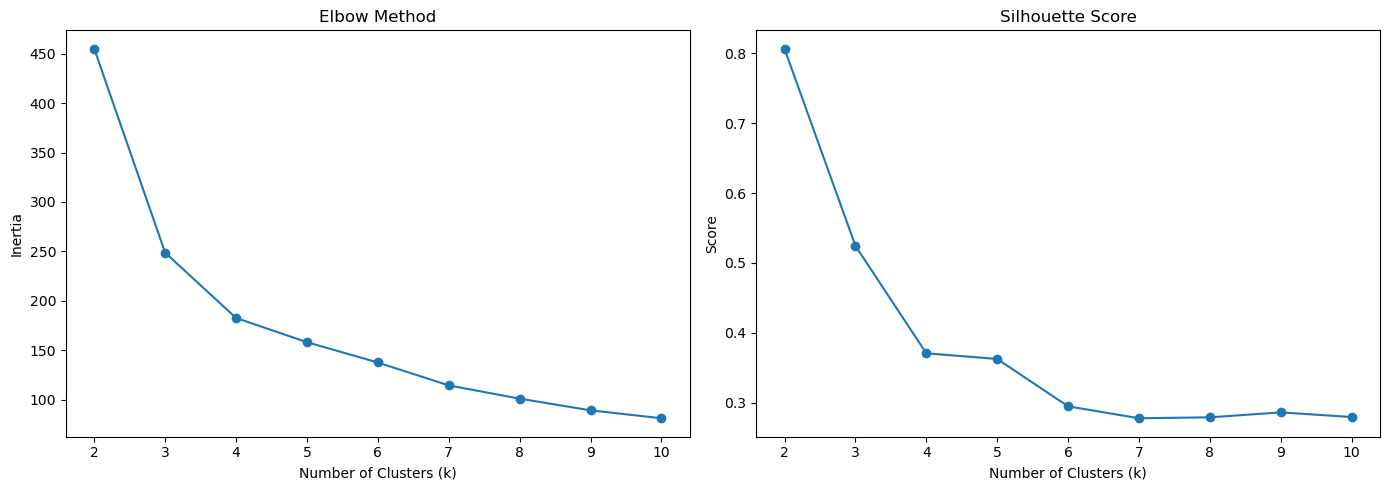

In [ ]:
def find_optimal_k(X_scaled, k_range=(2, 10)):
    inertia = []
    silhouette_scores = []
    K = range(k_range[0], k_range[1] + 1)

    for k in K:
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X_scaled)

        inertia.append(model.inertia_)
        silhouette_scores.append(silhouette_score(X_scaled, labels))

    return K, inertia, silhouette_scores


def plot_k_selection(K, inertia, silhouette_scores):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Elbow plot
    ax[0].plot(K, inertia, marker='o')
    ax[0].set_title("Elbow Method")
    ax[0].set_xlabel("Number of Clusters (k)")
    ax[0].set_ylabel("Inertia")

    # Silhouette plot
    ax[1].plot(K, silhouette_scores, marker='o')
    ax[1].set_title("Silhouette Score")
    ax[1].set_xlabel("Number of Clusters (k)")
    ax[1].set_ylabel("Score")

    plt.tight_layout()
    plt.show()


# Run
K, inertia, silhouette_scores = find_optimal_k(X_scaled)
plot_k_selection(K, inertia, silhouette_scores)

### Clustering

In [ ]:
def build_cluster_membership_table(df_input, cluster_col, country_col='Country'):
    df_sorted = df_input[[cluster_col, country_col]].sort_values([cluster_col, country_col]).reset_index(drop=True)
    return df_sorted


def build_cluster_summary_table(df_input, cluster_col, country_col='Country'):
    summary_table = (
        df_input.groupby(cluster_col)[country_col]
        .apply(list)
        .reset_index()
    )
    summary_table['Countries'] = summary_table[country_col].apply(lambda x: ', '.join(sorted(x)))
    summary_table['Country_Count'] = summary_table[country_col].apply(len)
    summary_table = summary_table[[cluster_col, 'Country_Count', 'Countries']]
    return summary_table.sort_values(cluster_col).reset_index(drop=True)


def build_cluster_profile_table(df_input, cluster_col, features):
    profile_table = (
        df_input.groupby(cluster_col)[features]
        .mean()
        .round(2)
        .reset_index()
        .sort_values(cluster_col)
        .reset_index(drop=True)
    )
    return profile_table

#### K-Means

In [ ]:
def apply_kmeans(X_scaled, df, k):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = model.fit_predict(X_scaled)

    df_clustered = df.copy()
    df_clustered['KMeans_Cluster'] = clusters

    return df_clustered, model


def build_cluster_summary_table_full(df_input, cluster_col, country_col='Country', line_break=False):
    summary_table = (
        df_input.groupby(cluster_col)[country_col]
        .apply(lambda x: sorted(x.tolist()))
        .reset_index()
    )

    summary_table['Country_Count'] = summary_table[country_col].apply(len)

    if line_break:
        summary_table['Countries'] = summary_table[country_col].apply(lambda x: '\n'.join(x))
    else:
        summary_table['Countries'] = summary_table[country_col].apply(lambda x: ', '.join(x))

    summary_table = summary_table[[cluster_col, 'Country_Count', 'Countries']]
    summary_table = summary_table.sort_values(cluster_col).reset_index(drop=True)

    return summary_table


def build_cluster_profile_table(df_input, cluster_col, features):
    profile_table = (
        df_input.groupby(cluster_col)[features]
        .mean()
        .round(2)
        .reset_index()
        .sort_values(cluster_col)
        .reset_index(drop=True)
    )
    return profile_table


def get_kmeans_outputs(df_clustered, features, line_break=False):
    kmeans_summary_table = build_cluster_summary_table_full(
        df_clustered,
        'KMeans_Cluster',
        line_break=line_break
    )
    kmeans_profile_table = build_cluster_profile_table(df_clustered, 'KMeans_Cluster', features)

    return kmeans_summary_table, kmeans_profile_table


def display_full_table(df_table):
    with pd.option_context(
        'display.max_colwidth', None,
        'display.max_rows', None,
        'display.max_columns', None,
        'display.width', None
    ):
        display(df_table)


# Run
k = 6

df_clustered, kmeans_model = apply_kmeans(X_scaled, df, k)

# Set line_break=True if you want each country on a separate line inside the cell
kmeans_summary_table, kmeans_profile_table = get_kmeans_outputs(
    df_clustered,
    features,
    line_break=False
)

print("KMeans Cluster Summary Table (Countries per Cluster):")
display_full_table(kmeans_summary_table)

print("KMeans Cluster Profile Table (Feature Averages):")
display_full_table(kmeans_profile_table)

KMeans Cluster Summary Table (Countries per Cluster):


c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,KMeans_Cluster,Country_Count,Countries
0,0,2,"China, US"
1,1,34,"Austria , Bahrain, Belgium , Brazil, Bulgaria, Chile, Colombia, Czech Rep., Egypt , Greece , Hungary, Iceland , India , Indonesia, Italy , Jordan , Lithuania, New Zealand, Oman, Peru, Philippines , Poland, Portugal, Qatar , Romania, Russia , Serbia , Slovenia, South Africa, Thailand , Turkey, Uruguay, Uzbekistan, Vietnam"
2,2,7,"Canada , European Union, France, Germany , Israel , South Korea , UK"
3,3,16,"Australia , Denmark, Estonia, Finland , Ireland, Japan , Luxembourg, Malaysia , Netherlands , Norway , Saudi Arabia, Spain, Sweden , Switzerland , Taiwan , UAE"
4,4,34,"Algeria, Argentina, Armenia, Azerbaijan, Bangladesh, Benin, Cambodia, Costa Rica, Croatia, Côte d'Ivoire, Dominican Rep., Ethiopia, Ghana, Iran, Iraq, Kenya, Kuwait, Latvia, Malta, Mauritius, Mexico, Morocco, Nepal, Nigeria, Pakistan, Rwanda, Senegal, Sierra Leone, Slovakia, Sri Lanka, Tajikistan, Tunisia, Ukraine, Zambia"
5,5,1,Singapore


KMeans Cluster Profile Table (Feature Averages):


,KMeans_Cluster,Talent,Infrastructure,Operating environment,Research,Development,Government strategy,Commercial ecosystem,Scale,Intensity
0,0,77.00,95.50,55.50,90.00,89.50,89.00,72.50,89.00,56.00
1,1,6.00,14.74,47.59,3.50,0.59,45.15,5.38,12.26,19.44
2,2,21.43,27.43,56.43,22.71,31.86,80.57,22.14,30.29,49.29
3,3,9.56,22.19,59.19,9.19,3.88,57.12,13.75,16.81,36.94
4,4,3.29,7.59,37.15,1.12,0.24,27.32,2.18,7.79,11.35
5,5,39.00,37.00,100.00,31.00,17.00,68.00,22.00,24.00,100.00


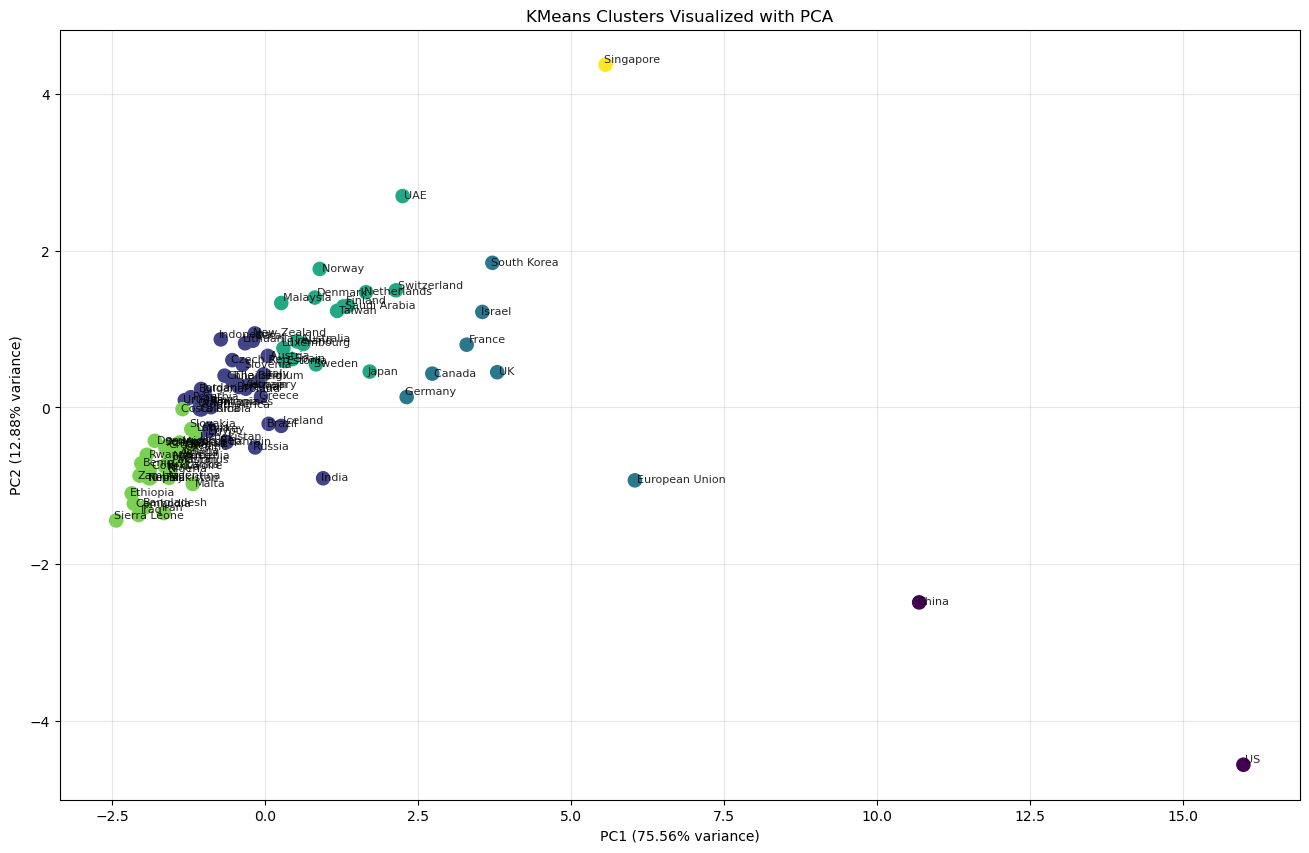

In [ ]:
def apply_pca(X_scaled, n_components=2):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    return X_pca, pca


def plot_kmeans_clusters(X_scaled, df_clustered, figsize=(16, 10), annotate=True):
    X_pca, pca_model = apply_pca(X_scaled, n_components=2)

    plt.figure(figsize=figsize)
    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=df_clustered['KMeans_Cluster'],
        s=90
    )

    if annotate:
        for i, country in enumerate(df_clustered['Country']):
            x = X_pca[i, 0]
            y = X_pca[i, 1]
            offset_x = 0.03 if i % 2 == 0 else -0.03
            offset_y = 0.03 if i % 3 == 0 else -0.03

            plt.annotate(
                country,
                (x, y),
                xytext=(x + offset_x, y + offset_y),
                textcoords='data',
                fontsize=8,
                alpha=0.85
            )

    explained_var = pca_model.explained_variance_ratio_

    plt.title('KMeans Clusters Visualized with PCA')
    plt.xlabel(f'PC1 ({explained_var[0] * 100:.2f}% variance)')
    plt.ylabel(f'PC2 ({explained_var[1] * 100:.2f}% variance)')
    plt.grid(alpha=0.3)
    plt.show()

    return X_pca, pca_model


# Run
X_pca_kmeans, pca_model_kmeans = plot_kmeans_clusters(X_scaled, df_clustered)

#### Dendogram

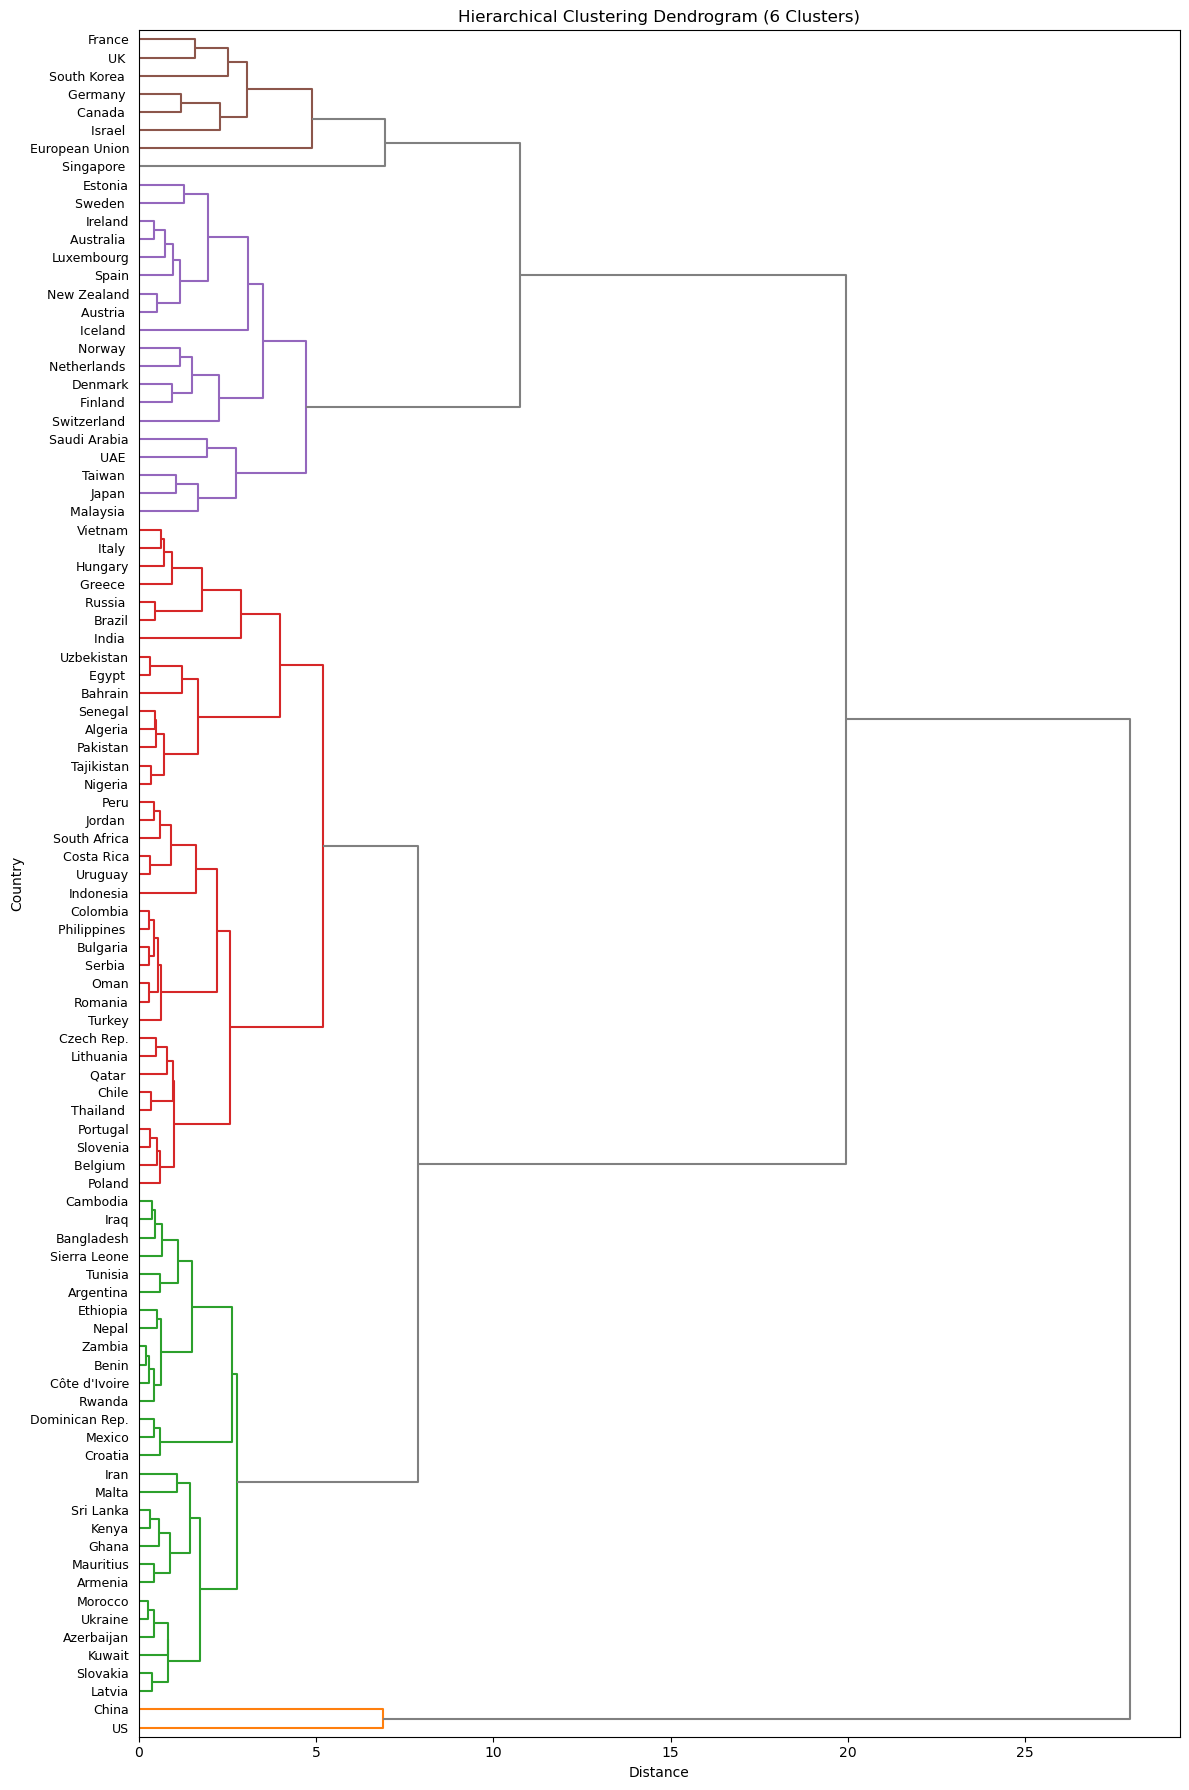

In [ ]:
def plot_dendrogram_with_k_colors(X_scaled, country_labels, k=6, method='ward'):
    linked = linkage(X_scaled, method=method)

    # Get cluster assignments
    cluster_labels = fcluster(linked, k, criterion='maxclust')

    # Find threshold that produces k clusters
    # This is the distance at which clusters merge into k groups
    distances = linked[:, 2]
    threshold = distances[-(k - 1)]  # key trick

    plt.figure(figsize=(12, 18))
    dendrogram(
        linked,
        labels=country_labels,
        orientation='right',
        leaf_rotation=0,
        leaf_font_size=9,
        color_threshold=threshold,   # <-- controls coloring
        above_threshold_color='grey'
    )

    plt.title(f'Hierarchical Clustering Dendrogram ({k} Clusters)')
    plt.xlabel('Distance')
    plt.ylabel('Country')
    plt.tight_layout()
    plt.show()

    return cluster_labels


# Run
dendro_clusters = plot_dendrogram_with_k_colors(
    X_scaled,
    df['Country'].values,
    k=6,
    method='ward'
)

#### Agglomeration

In [ ]:
def apply_agglomerative(X_scaled, df, k):
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(X_scaled)

    df_agg = df.copy()
    df_agg['Agg_Cluster'] = labels

    return df_agg, model


def build_cluster_summary_table_full(df_input, cluster_col, country_col='Country', line_break=False):
    summary_table = (
        df_input.groupby(cluster_col)[country_col]
        .apply(lambda x: sorted(x.tolist()))
        .reset_index()
    )

    summary_table['Country_Count'] = summary_table[country_col].apply(len)

    if line_break:
        summary_table['Countries'] = summary_table[country_col].apply(lambda x: '\n'.join(x))
    else:
        summary_table['Countries'] = summary_table[country_col].apply(lambda x: ', '.join(x))

    summary_table = summary_table[[cluster_col, 'Country_Count', 'Countries']]
    summary_table = summary_table.sort_values(cluster_col).reset_index(drop=True)

    return summary_table


def build_cluster_profile_table(df_input, cluster_col, features):
    profile_table = (
        df_input.groupby(cluster_col)[features]
        .mean()
        .round(2)
        .reset_index()
        .sort_values(cluster_col)
        .reset_index(drop=True)
    )
    return profile_table


def get_agglomerative_outputs(df_agg, features, line_break=False):
    agg_summary_table = build_cluster_summary_table_full(
        df_agg,
        'Agg_Cluster',
        line_break=line_break
    )
    agg_profile_table = build_cluster_profile_table(df_agg, 'Agg_Cluster', features)

    return agg_summary_table, agg_profile_table


def display_full_table(df_table):
    with pd.option_context(
        'display.max_colwidth', None,
        'display.max_rows', None,
        'display.max_columns', None,
        'display.width', None
    ):
        display(df_table)


# Run
k = 6

df_agg, agg_model = apply_agglomerative(X_scaled, df, k)

# Set line_break=True if you want each country on a separate line inside the cell
agg_summary_table, agg_profile_table = get_agglomerative_outputs(
    df_agg,
    features,
    line_break=False
)

print("Agglomerative Cluster Summary Table (Countries per Cluster):")
display_full_table(agg_summary_table)

print("Agglomerative Cluster Profile Table (Feature Averages):")
display_full_table(agg_profile_table)

Agglomerative Cluster Summary Table (Countries per Cluster):


,Agg_Cluster,Country_Count,Countries
0,0,2,"China, US"
1,1,7,"Canada , European Union, France, Germany , Israel , South Korea , UK"
2,2,37,"Algeria, Bahrain, Belgium , Brazil, Bulgaria, Chile, Colombia, Costa Rica, Czech Rep., Egypt , Greece , Hungary, India , Indonesia, Italy , Jordan , Lithuania, Nigeria, Oman, Pakistan, Peru, Philippines , Poland, Portugal, Qatar , Romania, Russia , Senegal, Serbia , Slovenia, South Africa, Tajikistan, Thailand , Turkey, Uruguay, Uzbekistan, Vietnam"
3,3,19,"Australia , Austria , Denmark, Estonia, Finland , Iceland , Ireland, Japan , Luxembourg, Malaysia , Netherlands , New Zealand, Norway , Saudi Arabia, Spain, Sweden , Switzerland , Taiwan , UAE"
4,4,28,"Argentina, Armenia, Azerbaijan, Bangladesh, Benin, Cambodia, Croatia, Côte d'Ivoire, Dominican Rep., Ethiopia, Ghana, Iran, Iraq, Kenya, Kuwait, Latvia, Malta, Mauritius, Mexico, Morocco, Nepal, Rwanda, Sierra Leone, Slovakia, Sri Lanka, Tunisia, Ukraine, Zambia"
5,5,1,Singapore


Agglomerative Cluster Profile Table (Feature Averages):


,Agg_Cluster,Talent,Infrastructure,Operating environment,Research,Development,Government strategy,Commercial ecosystem,Scale,Intensity
0,0,77.00,95.50,55.50,90.00,89.50,89.00,72.50,89.00,56.00
1,1,21.43,27.43,56.43,22.71,31.86,80.57,22.14,30.29,49.29
2,2,5.65,12.70,45.51,2.70,0.35,45.30,4.46,11.81,17.03
3,3,8.89,22.21,57.84,9.00,3.63,53.68,12.95,16.00,36.37
4,4,3.25,7.93,37.32,1.18,0.29,24.36,2.36,7.50,11.32
5,5,39.00,37.00,100.00,31.00,17.00,68.00,22.00,24.00,100.00


In [ ]:
def get_canada_cluster_members(df_clustered, df_agg, target_country='Canada'):
    # Create cleaned country columns for safe matching
    df_clustered_clean = df_clustered.copy()
    df_agg_clean = df_agg.copy()

    df_clustered_clean['Country_Clean'] = df_clustered_clean['Country'].astype(str).str.strip()
    df_agg_clean['Country_Clean'] = df_agg_clean['Country'].astype(str).str.strip()

    target_country = target_country.strip()

    # --- KMeans ---
    kmeans_match = df_clustered_clean.loc[
        df_clustered_clean['Country_Clean'] == target_country, 'KMeans_Cluster'
    ]

    if kmeans_match.empty:
        raise ValueError(f"'{target_country}' not found in df_clustered['Country']")

    canada_kmeans_cluster = kmeans_match.iloc[0]

    kmeans_countries = (
        df_clustered_clean.loc[
            df_clustered_clean['KMeans_Cluster'] == canada_kmeans_cluster, 'Country_Clean'
        ]
        .sort_values()
        .tolist()
    )

    # --- Agglomerative ---
    agg_match = df_agg_clean.loc[
        df_agg_clean['Country_Clean'] == target_country, 'Agg_Cluster'
    ]

    if agg_match.empty:
        raise ValueError(f"'{target_country}' not found in df_agg['Country']")

    canada_agg_cluster = agg_match.iloc[0]

    agg_countries = (
        df_agg_clean.loc[
            df_agg_clean['Agg_Cluster'] == canada_agg_cluster, 'Country_Clean'
        ]
        .sort_values()
        .tolist()
    )

    # --- Output table ---
    result = pd.DataFrame({
        'Method': ['KMeans', 'Agglomerative'],
        'Cluster': [canada_kmeans_cluster, canada_agg_cluster],
        'Country_Count': [len(kmeans_countries), len(agg_countries)],
        'Countries': [
            ', '.join(kmeans_countries),
            ', '.join(agg_countries)
        ]
    })

    return result

In [ ]:
def display_wrapped_table(df_table):
    styled_table = df_table.style.set_properties(
        subset=df_table.columns,
        **{
            'white-space': 'pre-wrap',
            'text-align': 'left',
            'max-width': '500px'
        }
    )
    display(styled_table)

### Countries with CANADA in Clusters

In [ ]:
canada_cluster_table = get_canada_cluster_members(df_clustered, df_agg)

print("Countries in the same cluster as Canada:")
display_wrapped_table(canada_cluster_table)

Countries in the same cluster as Canada:


,Method,Cluster,Country_Count,Countries
0,KMeans,2,7,"Canada, European Union, France, Germany, Israel, South Korea, UK"
1,Agglomerative,1,7,"Canada, European Union, France, Germany, Israel, South Korea, UK"


In [ ]:
dendrogram_countries = [
    'Canada',
    'European Union',
    'France',
    'Germany',
    'Israel',
    'South Korea',
    'UK',
    'Singapore'
]

# Choose formatting
countries_text = ', '.join(dendrogram_countries)  # or use ', '.join(...) if you prefer

dendrogram_row = pd.DataFrame({
    'Method': ['Dendrogram'],
    'Cluster': ['Canada Cluster'],
    'Country_Count': [len(dendrogram_countries)],
    'Countries': [countries_text]
})

# Append to existing table
canada_cluster_table = pd.concat(
    [canada_cluster_table, dendrogram_row],
    ignore_index=True
)

print("Countries in the same cluster as Canada:")
display_wrapped_table(canada_cluster_table)

Countries in the same cluster as Canada:


,Method,Cluster,Country_Count,Countries
0,KMeans,2,7,"Canada, European Union, France, Germany, Israel, South Korea, UK"
1,Agglomerative,1,7,"Canada, European Union, France, Germany, Israel, South Korea, UK"
2,Dendrogram,Canada Cluster,8,"Canada, European Union, France, Germany, Israel, South Korea, UK, Singapore"


### Figures

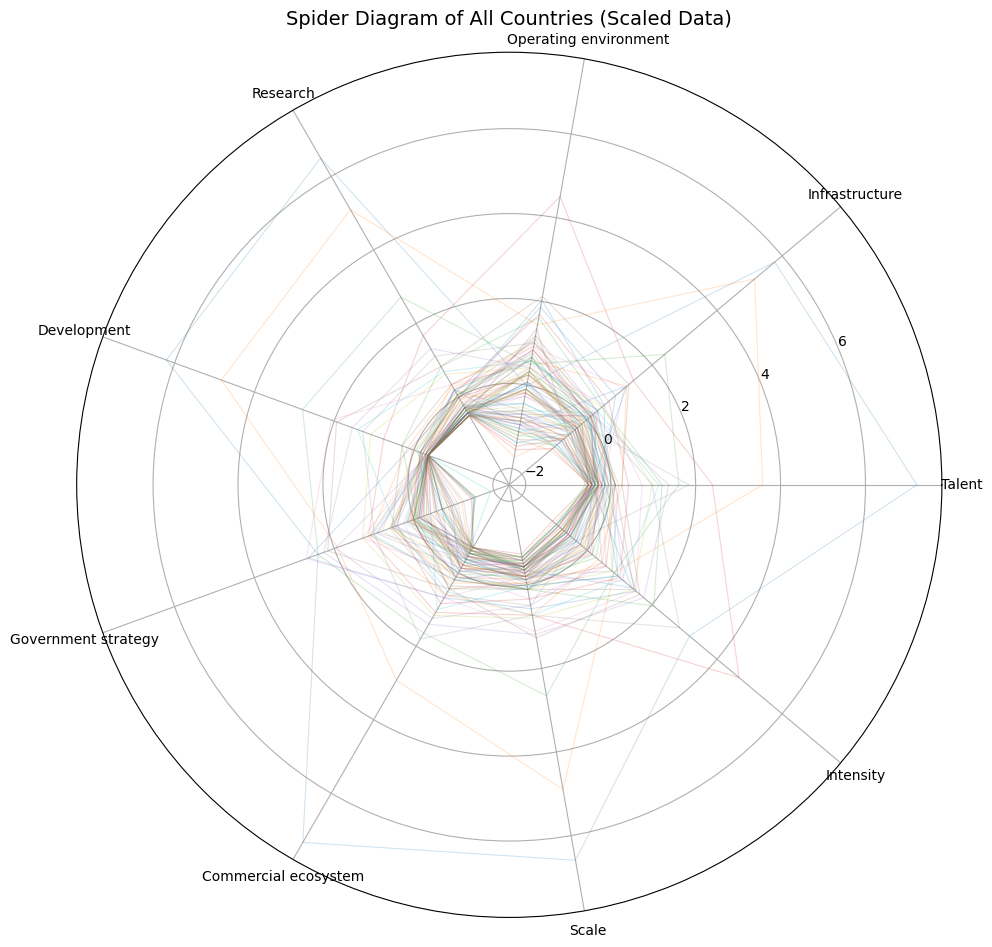

In [ ]:
df_scaled = pd.DataFrame(X_scaled, columns=features)
df_scaled['Country'] = df['Country'].astype(str).str.strip()

num_vars = len(features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

for i in range(len(df_scaled)):
    values = df_scaled.loc[i, features].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=0.8, alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=10)

plt.title('Spider Diagram of All Countries (Scaled Data)', size=14, pad=20)
plt.tight_layout()
plt.show()

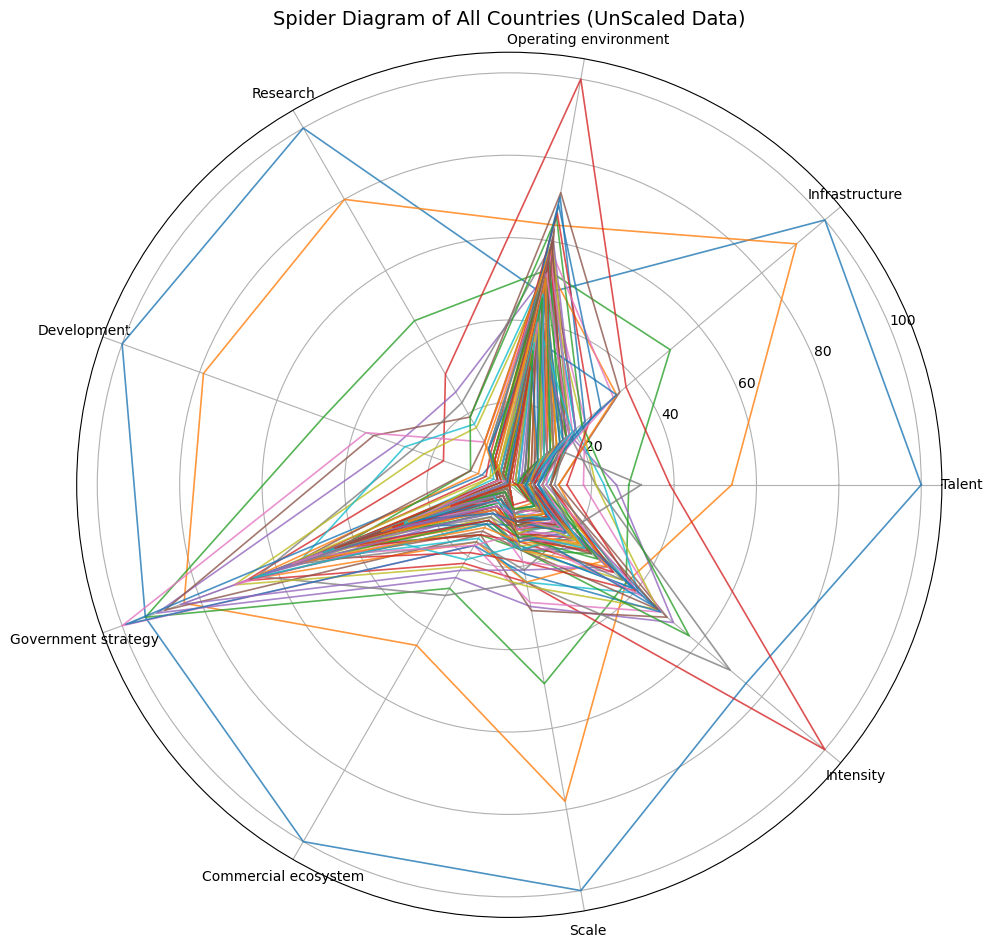

In [ ]:
df_scaled = pd.DataFrame(X, columns=features)
df_scaled['Country'] = df['Country'].astype(str).str.strip()

num_vars = len(features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

for i in range(len(df_scaled)):
    values = df_scaled.loc[i, features].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=1.2, alpha=0.8)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=10)

plt.title('Spider Diagram of All Countries (UnScaled Data)', size=14, pad=20)
plt.tight_layout()
plt.show()

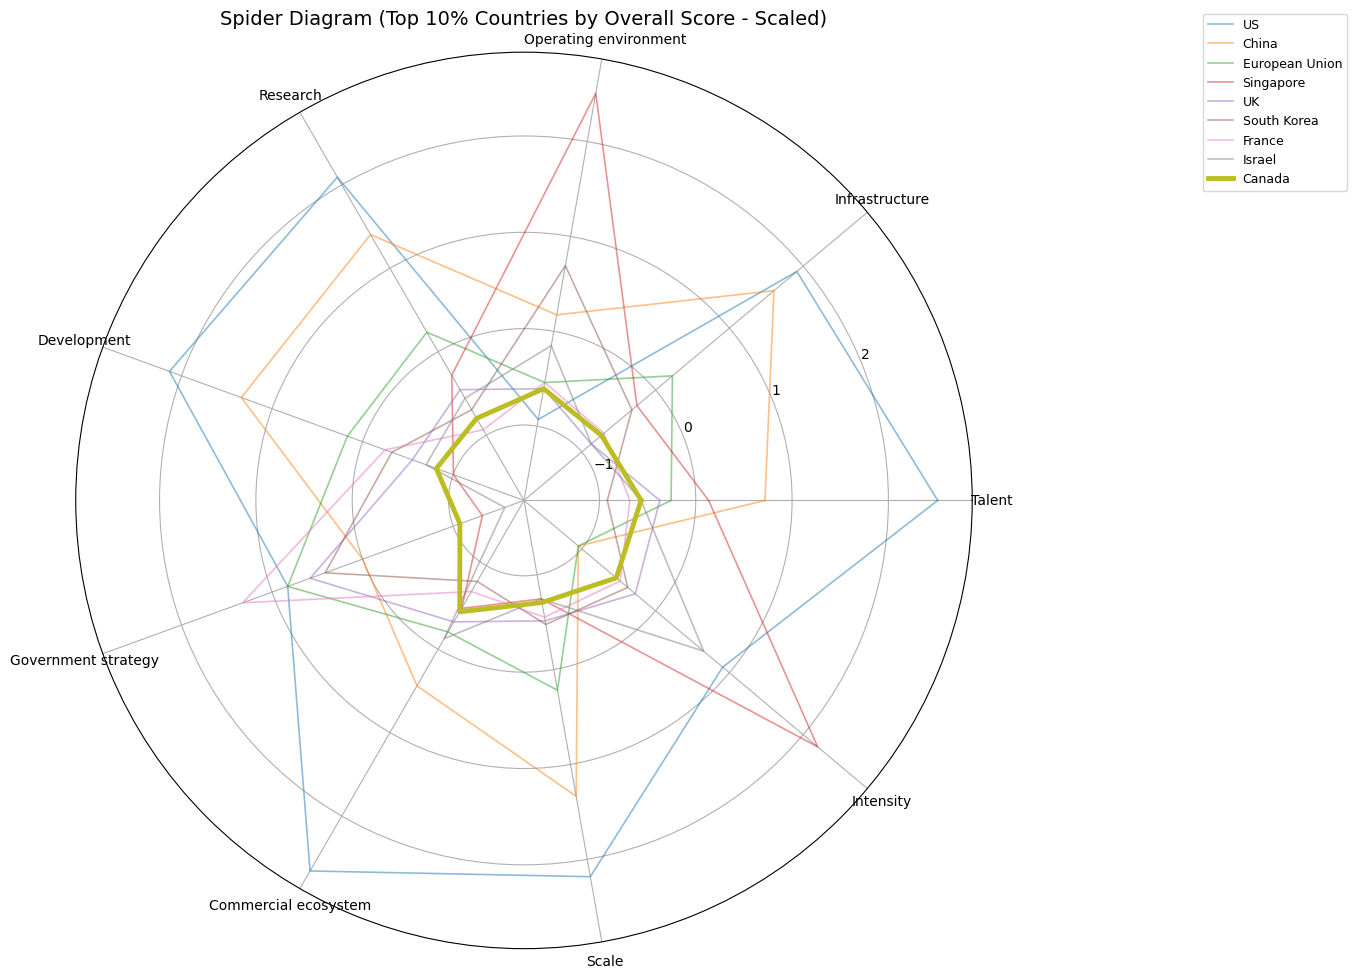

In [ ]:
# Step 1: Filter countries above 90th percentile
threshold = df['Overall'].quantile(0.90)
df_top = df[df['Overall'] > threshold].copy()

# Step 2: Scale ONLY the filtered data
scaler_top = StandardScaler()
X_top_scaled = scaler_top.fit_transform(df_top[features])

# Step 3: Create scaled DataFrame
df_top_scaled = pd.DataFrame(X_top_scaled, columns=features)
df_top_scaled['Country'] = df_top['Country'].astype(str).str.strip()

# Step 4: Radar chart setup
num_vars = len(features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(14, 14))
ax = plt.subplot(111, polar=True)

# Step 5: Plot each country WITH labels
for i in range(len(df_top_scaled)):
    values = df_top_scaled.loc[i, features].tolist()
    values += values[:1]

    country = df_top_scaled.loc[i, 'Country']

    # Highlight Canada
    if country == 'Canada':
        ax.plot(
            angles,
            values,
            linewidth=3.5,   # thicker line
            alpha=1.0,
            label=country
        )
    else:
        ax.plot(
            angles,
            values,
            linewidth=1.2,
            alpha=0.5,
            label=country
        )
# Step 6: Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=10)

plt.title('Spider Diagram (Top 10% Countries by Overall Score - Scaled)', size=14, pad=20)

# Step 7: Legend on the side
plt.legend(
    bbox_to_anchor=(1.25, 1.05),
    loc='upper left',
    fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.show()

In [ ]:
# Step 4: Find the country with the highest scaled score in each feature
best_feature_rows = []

for feature in features:
    max_idx = df_top_scaled[feature].idxmax()
    best_feature_rows.append({
        'Feature': feature,
        'Best_Country': df_top_scaled.loc[max_idx, 'Country'],
        'Best_Scaled_Score': df_top_scaled.loc[max_idx, feature]
    })

best_feature_table = pd.DataFrame(best_feature_rows)

print("Best country in each feature after filtering to top 10% by Overall:")
display(best_feature_table)

Best country in each feature after filtering to top 10% by Overall:


,Feature,Best_Country,Best_Scaled_Score
0,Talent,US,2.511411
1,Infrastructure,US,1.913859
2,Operating environment,Singapore,2.507559
3,Research,US,2.091843
4,Development,US,2.132685
5,Government strategy,France,1.323163
6,Commercial ecosystem,US,2.658364
7,Scale,US,2.183078
8,Intensity,Singapore,2.196474


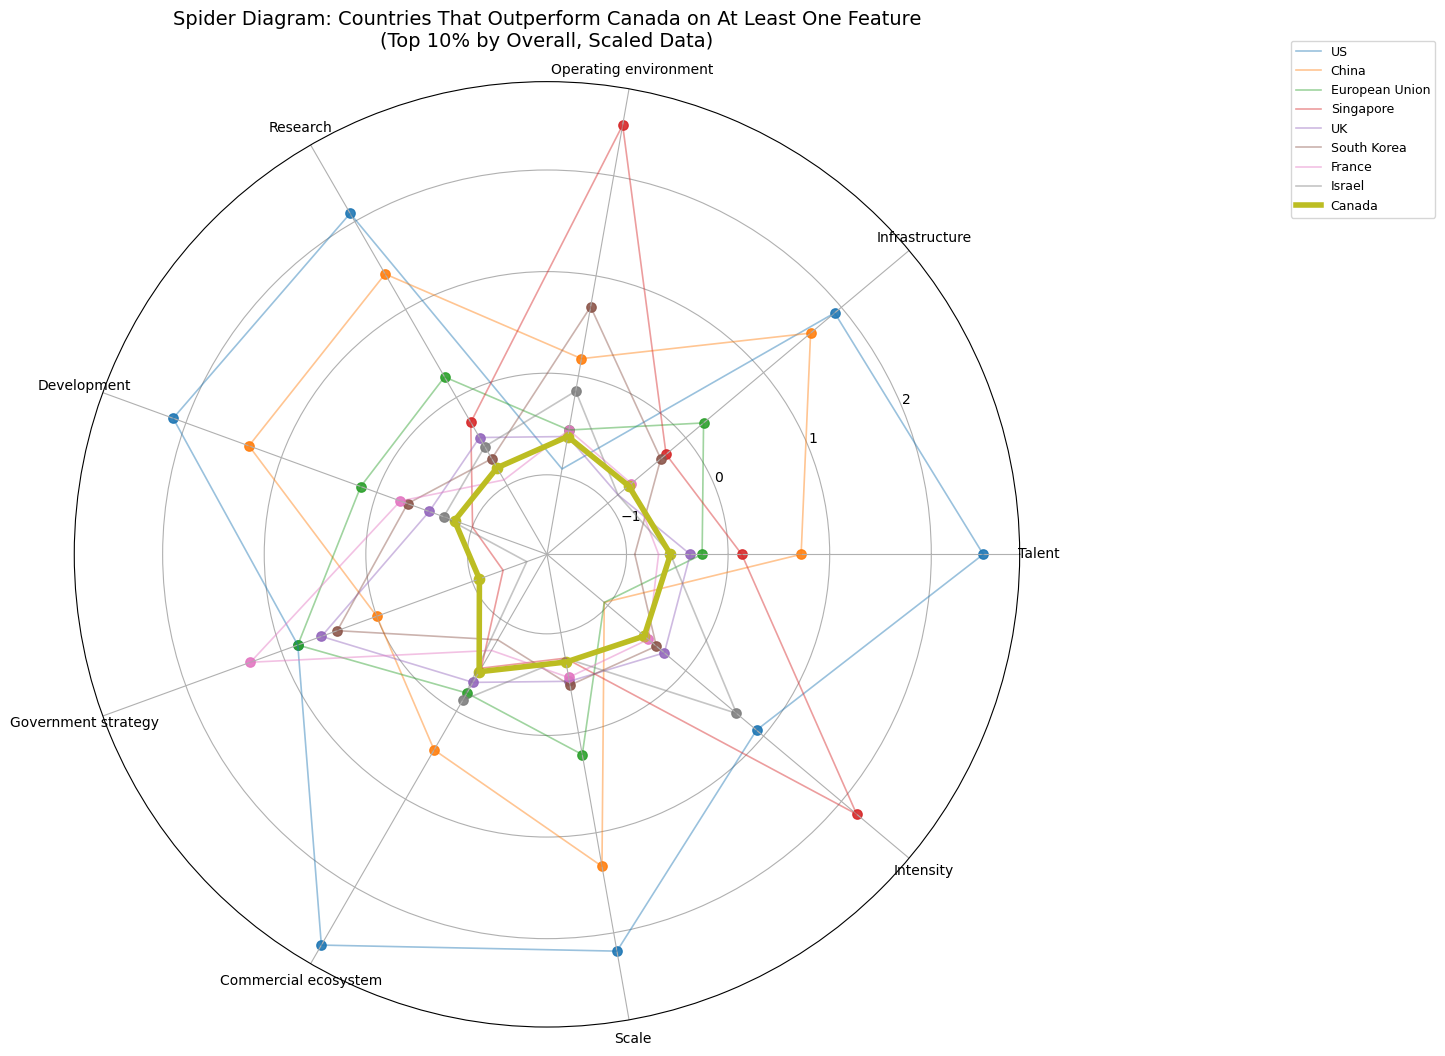

In [ ]:
# Step 1: Filter countries above 90th percentile based on Overall
threshold = df['Overall'].quantile(0.90)
df_top = df[df['Overall'] > threshold].copy()

# Step 2: Scale only the filtered data
scaler_top = StandardScaler()
X_top_scaled = scaler_top.fit_transform(df_top[features])

# Step 3: Create scaled DataFrame
df_top_scaled = pd.DataFrame(X_top_scaled, columns=features)
df_top_scaled['Country'] = df_top['Country'].astype(str).str.strip()

# Step 4: Get Canada's scaled scores
canada_row = df_top_scaled[df_top_scaled['Country'] == 'Canada'].copy()

if canada_row.empty:
    raise ValueError("Canada is not present in the filtered top 90th percentile data.")

canada_scores = canada_row.iloc[0][features]

# Step 5: Keep only countries that beat Canada on at least one feature
comparison_mask = (df_top_scaled[features] > canada_scores.values).any(axis=1)
df_better_than_canada = df_top_scaled[comparison_mask].copy()

# Keep Canada in the chart even if already included/excluded
df_plot = pd.concat([
    canada_row,
    df_better_than_canada[df_better_than_canada['Country'] != 'Canada']
], ignore_index=True)

# Step 6: Radar chart setup
num_vars = len(features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(15, 15))
ax = plt.subplot(111, polar=True)

# Step 7: Plot non-Canada countries and highlight points where they beat Canada
for i in range(len(df_plot)):
    country = df_plot.loc[i, 'Country']
    values = df_plot.loc[i, features].tolist()
    values_closed = values + values[:1]

    if country == 'Canada':
        continue

    ax.plot(
        angles,
        values_closed,
        linewidth=1.2,
        alpha=0.45,
        label=country
    )

    # Highlight feature points where this country beats Canada
    better_features_mask = df_plot.loc[i, features].values > canada_scores.values
    better_angles = [angles[j] for j in range(num_vars) if better_features_mask[j]]
    better_values = [values[j] for j in range(num_vars) if better_features_mask[j]]

    if len(better_angles) > 0:
        ax.scatter(
            better_angles,
            better_values,
            s=45,
            alpha=0.9
        )

# Step 8: Plot Canada last so it stays visually on top
canada_values = canada_scores.tolist()
canada_values_closed = canada_values + canada_values[:1]

ax.plot(
    angles,
    canada_values_closed,
    linewidth=4,
    alpha=1.0,
    label='Canada'
)

# Optional: mark Canada's own points
ax.scatter(
    angles[:-1],
    canada_values,
    s=55,
    alpha=1.0
)

# Step 9: Axis labels and title
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=10)

plt.title(
    'Spider Diagram: Countries That Outperform Canada on At Least One Feature\n(Top 10% by Overall, Scaled Data)',
    size=14,
    pad=25
)

# Step 10: Legend on the side
plt.legend(
    bbox_to_anchor=(1.28, 1.05),
    loc='upper left',
    fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.show()

In [ ]:
# Extract Canada's current row
canada_performance = df[df['Country'].astype(str).str.strip() == 'Canada'].copy()

# Keep only relevant columns and rename the country label
canada_performance = canada_performance[['Country', 'Overall'] + features].copy()
canada_performance.loc[:, 'Country'] = 'canada_performance'

display(canada_performance)

,Country,Overall,Talent,Infrastructure,Operating environment,Research,Development,Government strategy,Commercial ecosystem,Scale,Intensity
8,canada_performance,31,21,23,52,16,22,71,23,25,47


In [ ]:
# Create scenario rows from the current Canada baseline
canada_rd = canada_performance.copy()
canada_govt = canada_performance.copy()
canada_econ = canada_performance.copy()
canada_final = canada_performance.copy()

# Rename scenario rows
canada_rd.loc[:, 'Country'] = 'Canada_R&D'
canada_govt.loc[:, 'Country'] = 'Canada_Govt'
canada_econ.loc[:, 'Country'] = 'Canada_Econ'
canada_final.loc[:, 'Country'] = 'Canada_Final'

# Approximate policy-driven score increases
# 1) Translational R&D mission + sovereign compute + Mitacs/IRAP translational talent
rd_increase = {
    'Talent': 30,
    'Infrastructure': 25,
    'Operating environment':9,
    'Research': 29,
    'Development': 28,
    'Government strategy': 15,
    'Commercial ecosystem': 18,
    'Scale': 19,
    'Intensity': 15
}

# 2) Government-policy and strategic coordination improvements
govt_increase = {
    'Talent': 20,
    'Infrastructure': 26,
    'Operating environment': 29,
    'Research': 20,
    'Development': 30,
    'Government strategy': 30,
    'Commercial ecosystem': 15,
    'Scale': 13,
    'Intensity': 14
}

# 3) Economic / adoption / deployment improvements
econ_increase = {
    'Talent': 20,
    'Infrastructure': 20,
    'Operating environment': 24,
    'Research': 15,
    'Development': 25,
    'Government strategy': 23,
    'Commercial ecosystem': 30,
    'Scale': 16,
    'Intensity': 17
}

# Apply increases to each scenario row
for col, inc in rd_increase.items():
    canada_rd.loc[:, col] = np.minimum(canada_rd[col] + inc, 100)

for col, inc in govt_increase.items():
    canada_govt.loc[:, col] = np.minimum(canada_govt[col] + inc, 100)

for col, inc in econ_increase.items():
    canada_econ.loc[:, col] = np.minimum(canada_econ[col] + inc, 100)

# Final scenario = combined effect with dampening to avoid unrealistic full add-up
for col in features:
    total_increase = rd_increase[col] + govt_increase[col] + econ_increase[col]
    dampened_increase = round(total_increase * 0.75, 1)
    canada_final.loc[:, col] = np.minimum(canada_final[col] + dampened_increase, 100)

# Approximate Overall score update:
# Use average feature gain applied to current Overall, capped at 100
base_overall = float(canada_performance['Overall'].iloc[0])

rd_avg_gain = np.mean(list(rd_increase.values()))
govt_avg_gain = np.mean(list(govt_increase.values()))
econ_avg_gain = np.mean(list(econ_increase.values()))
final_avg_gain = np.mean([
    (rd_increase[col] + govt_increase[col] + econ_increase[col]) * 0.75
    for col in features
])

canada_rd.loc[:, 'Overall'] = min(base_overall + rd_avg_gain, 100)
canada_govt.loc[:, 'Overall'] = min(base_overall + govt_avg_gain, 100)
canada_econ.loc[:, 'Overall'] = min(base_overall + econ_avg_gain, 100)
canada_final.loc[:, 'Overall'] = min(base_overall + final_avg_gain, 100)

# Round numeric columns
numeric_cols = ['Overall'] + features
canada_rd[numeric_cols] = canada_rd[numeric_cols].round(1)
canada_govt[numeric_cols] = canada_govt[numeric_cols].round(1)
canada_econ[numeric_cols] = canada_econ[numeric_cols].round(1)
canada_final[numeric_cols] = canada_final[numeric_cols].round(1)

# Append all rows into canada_performance
canada_performance = pd.concat(
    [
        canada_performance,
        canada_rd,
        canada_govt,
        canada_econ,
        canada_final
    ],
    ignore_index=True
)

display(canada_performance)

C:\Users\admin\AppData\Local\Temp\ipykernel_34364\2153835389.py:67: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[73.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  canada_final.loc[:, col] = np.minimum(canada_final[col] + dampened_increase, 100)
C:\Users\admin\AppData\Local\Temp\ipykernel_34364\2153835389.py:67: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[76.2]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  canada_final.loc[:, col] = np.minimum(canada_final[col] + dampened_increase, 100)
C:\Users\admin\AppData\Local\Temp\ipykernel_34364\2153835389.py:67: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[98.5]' has dtype incompatible with int64, please explicitly cast to a compatible dt

,Country,Overall,Talent,Infrastructure,Operating environment,Research,Development,Government strategy,Commercial ecosystem,Scale,Intensity
0,canada_performance,31.0,21.0,23.0,52.0,16,22.0,71,23.0,25,47.0
1,Canada_R&D,51.9,51.0,48.0,61.0,45,50.0,86,41.0,44,62.0
2,Canada_Govt,52.9,41.0,49.0,81.0,36,52.0,100,38.0,38,61.0
3,Canada_Econ,52.1,41.0,43.0,76.0,31,47.0,94,53.0,41,64.0
4,Canada_Final,78.9,73.5,76.2,98.5,64,84.2,100,70.2,61,81.5


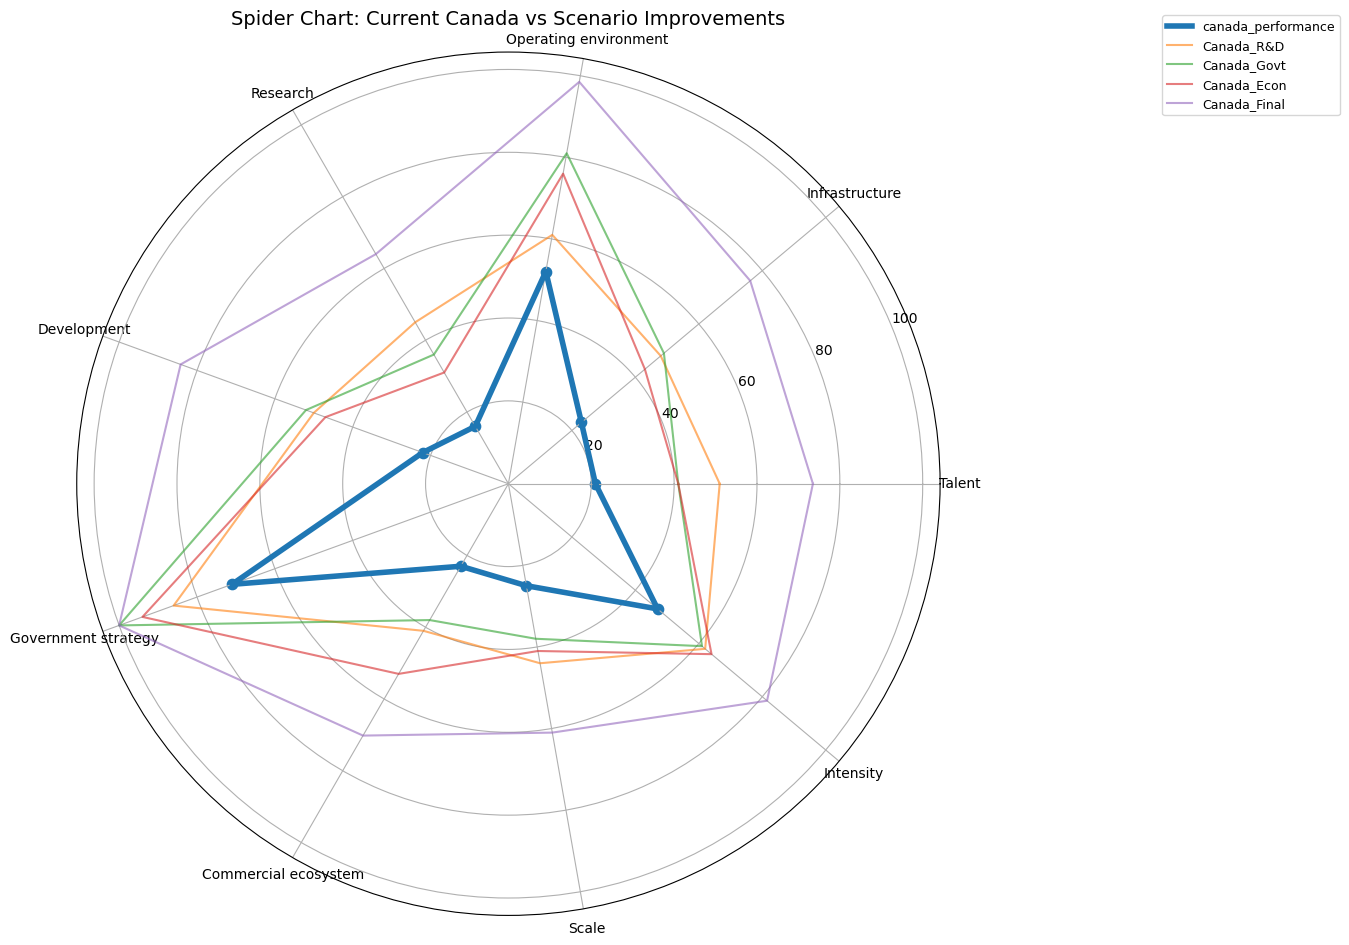

In [ ]:
# Assume canada_performance already exists and contains:
# canada_performance, Canada_R&D, Canada_Govt, Canada_Econ, Canada_Final

# Clean country labels just in case
canada_performance['Country'] = canada_performance['Country'].astype(str).str.strip()

# Radar chart setup
num_vars = len(features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(14, 14))
ax = plt.subplot(111, polar=True)

# Plot all rows, highlighting canada_performance
for i in range(len(canada_performance)):
    country = canada_performance.loc[i, 'Country']
    values = canada_performance.loc[i, features].tolist()
    values += values[:1]

    if country == 'canada_performance':
        ax.plot(
            angles,
            values,
            linewidth=4,
            alpha=1.0,
            label=country
        )
        ax.scatter(
            angles[:-1],
            canada_performance.loc[i, features].tolist(),
            s=55,
            alpha=1.0
        )
    else:
        ax.plot(
            angles,
            values,
            linewidth=1.5,
            alpha=0.6,
            label=country
        )

# Axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=10)

plt.title('Spider Chart: Current Canada vs Scenario Improvements', size=14, pad=20)

# Legend on the side
plt.legend(
    bbox_to_anchor=(1.25, 1.05),
    loc='upper left',
    fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.show()